In [1]:
import edes 
from edes.utils.plotting import plot, plot_ax, big_plt_font, plot_ax_errbar, plot_errbar
from edes.modules.detection.detection_utils import dB_to_frac, frac_to_dB, dBm_to_W, W_to_dBm
import numpy as np 
from tqdm import tqdm, trange 
import matplotlib.pyplot as plt 
import time
from edes.utils.file_handling import load_h5_data, load_latest_data, load_latest_filename, list_filenames
import scipy.constants as spc
big_plt_font()

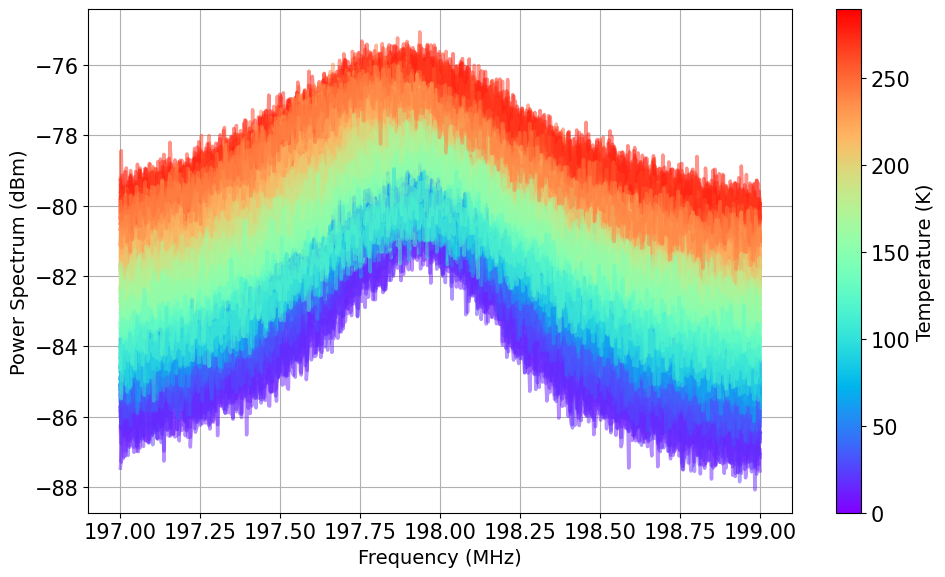

In [2]:
import matplotlib.colors as colors
base = r'/home/electron/data/warmup_06062026/resonator'
all_files = [i for i in list_filenames(base) if 'E' not in i]
cmap = plt.cm.rainbow 
norm = colors.Normalize(vmin=0, vmax=290)
fig = plt.figure(figsize=(10,6))
for filename in all_files: 
    file = np.load(f'{base}/{filename}', allow_pickle=True)
    freq, power = file['freq'], file['data']
    color = cmap(norm(float(filename[:-4]))) 
    plot(freq, power, c=color, alpha=0.5, xlabel='Frequency (MHz)', ylabel='Power Spectrum (dBm)')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) # Dummy array required for matplotlib versions

# 4. Draw the colorbar using the ScalarMappable
ax = plt.gca() # Gets the current active axes
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Temperature (K)') 
plt.tight_layout()
plt.show()

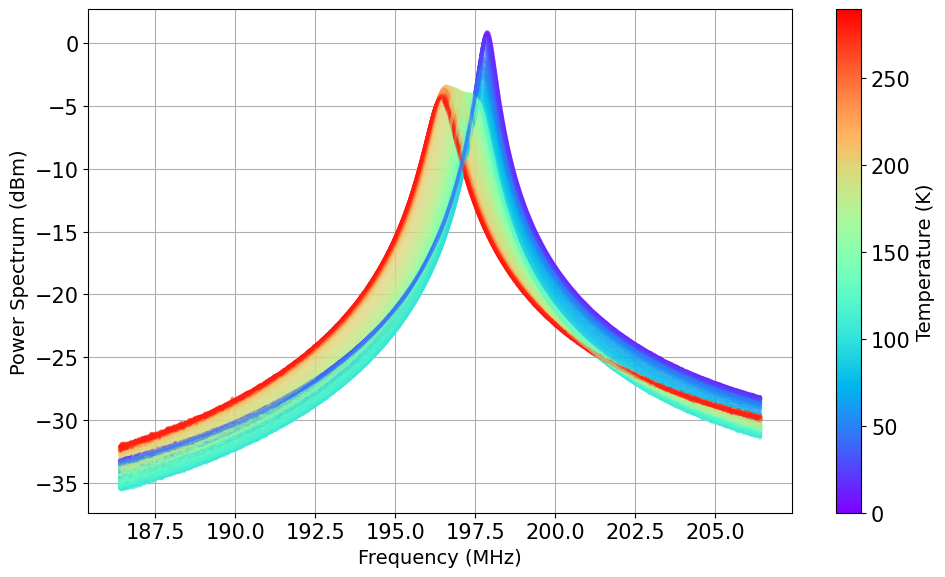

In [3]:
import matplotlib.colors as colors
base = r'/home/electron/data/cooldown_06122026/resonator'
all_files = [i for i in list_filenames(base) if 'E' not in i]
cmap = plt.cm.rainbow
norm = colors.Normalize(vmin=0, vmax=290)
fig = plt.figure(figsize=(10,6))
for filename in all_files: 
    file = np.load(f'{base}/{filename}', allow_pickle=True)
    # print(file.keys())
    freq, power = file['freq'], file['mag']
    color = cmap(norm(float(filename[:-4]))) 
    plot(freq/1e6, power, c=color, alpha=0.5, xlabel='Frequency (MHz)', ylabel='Power Spectrum (dBm)')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) # Dummy array required for matplotlib versions

# 4. Draw the colorbar using the ScalarMappable
ax = plt.gca() # Gets the current active axes
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Temperature (K)') 
plt.tight_layout()
plt.show()

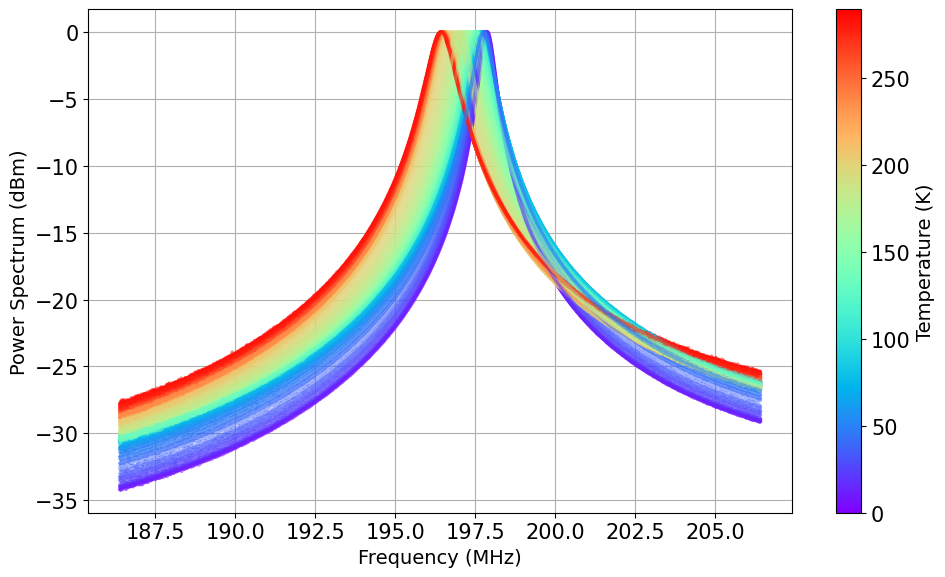

In [4]:
import matplotlib.colors as colors
base = r'/home/electron/data/cooldown_06122026/resonator'
all_files = [i for i in list_filenames(base) if 'E' not in i]
cmap = plt.cm.rainbow
norm = colors.Normalize(vmin=0, vmax=290)
fig = plt.figure(figsize=(10,6))
for filename in all_files: 
    file = np.load(f'{base}/{filename}', allow_pickle=True)
    # print(file.keys())
    freq, power = file['freq'], file['mag']-max(file['mag'])
    color = cmap(norm(float(filename[:-4]))) 
    plot(freq/1e6, power, c=color, alpha=0.5, xlabel='Frequency (MHz)', ylabel='Power Spectrum (dBm)')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) # Dummy array required for matplotlib versions

# 4. Draw the colorbar using the ScalarMappable
ax = plt.gca() # Gets the current active axes
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Temperature (K)') 
plt.tight_layout()
plt.show()

In [5]:
from resonator_tools import circuit 
from resonator_tools.utilities import plotting
# from edes.modules.VNA.VNA_utils import plotting

def S21(f,f0,Q,Qc,a,t):
    #constant phase offset
    phase1 = np.exp(1j*0)
    #frequency dependent phase
    phase2 = np.exp(-2*np.pi*1j*f*0)
    #ideal resonator
    F = (Q/Qc)/(1+2*1j*Q*(f-f0)/f0)

    #real and imaginary components
    S21_complex = phase1*phase2*F
    S21_re = np.real(S21_complex)
    S21_im = np.imag(S21_complex)

    return np.concatenate((S21_re,S21_im))

def S11(f,f0,Q,Qc,a,t):
    #constant phase offset
    phase1 = np.exp(1j*0)
    #frequency dependent phase
    phase2 = np.exp(-2*np.pi*1j*f*0)
    #ideal resonator
    F = (1 - 2*(Q/Qc)/(1+2*1j*Q*(f-f0)/f0))

    #real and imaginary components
    S21_complex = phase1*phase2*F
    S21_re = np.real(S21_complex)
    S21_im = np.imag(S21_complex)

    return np.concatenate((S21_re,S21_im))

def vec_S21(S21_concat):
    l = int(len(S21_concat)/2)
    r = S21_concat[:l]
    i = S21_concat[l:]
    return [r,i]

def vec_S11(S11_concat):
    l = int(len(S11_concat)/2)
    r = S11_concat[:l]
    i = S11_concat[l:]
    return [r,i]

def mag_S21(re_s21, im_s21):
    return (np.sqrt(re_s21**2+im_s21**2))

def phase_S21(re_s21, im_s21):
    return np.arctan(im_s21/re_s21)

def get_Qi(Q, Qc):
    return 1 / (1/Q - 1/Qc)

def fit_S21(s2p_file, pi = [270e6,500,1000,0,0], C='blue', slabel='', start=185e6, stop=205e6):
  filepath = s2p_file
  df = pd.read_csv(filepath,skiprows=6,names=['S11', 'S21', 'freq'])

  freqs_np = np.array(df.freq)
  ReS21 = np.array(df['S21']).astype(complex).real
  ImS21 = np.array(df['S21']).astype(complex).imag

  magS21 = np.sqrt(ReS21**2+ImS21**2)

  

  max_freq = (freqs_np[np.where(magS21==np.max(magS21))])

  start = 250e6  #max_freq[0]-3e6
  stop= 300e6  #max_freq[0]+3e6


  min_index = np.min(np.where(freqs_np>=start)[0])
  max_index = np.max(np.where(freqs_np<=stop)[0])


  reS21_np = np.array(ReS21)[min_index:max_index]
  imS21_np = np.array(ImS21)[min_index:max_index]
  freqs=freqs_np[min_index:max_index]
  pi[0] = max_freq[0] 
    

  S21_data = np.concatenate((reS21_np,imS21_np))

  params, pcov = curve_fit(S21, freqs, S21_data,p0=pi)

  S21_Concat = S21(freqs,params[0],params[1],params[2],0,0)#,params[3],params[4])
  S21_Vec = vec_S21(S21_Concat)

  #plt.plot(freqs/1e6, mag_S21(S21_Vec[0],S21_Vec[1]),'.',color='r', label=f'Q = {round(params[1],2)}')

  S21_mags = np.sqrt(S21_Vec[0]**2+S21_Vec[1]**2)

  plt.plot(freqs/1e6,S21_mags,color=C, label=slabel+f'Q = {round(params[1],2)}')
  plt.xlabel('frequency (MHZ)')
  plt.ylabel('mag(S21)')
  plt.legend()

  
  return params

def fit_S11(s2p_file, pi = [227e6,200,100,0,0], C='blue', slabel='', start=185e6, stop=205e6):
  filepath = s2p_file
  #df = pd.read_csv(filepath,skiprows=6,names=['S11', 'S21', 'freq'])
  df = pd.read_csv(filepath)

  freqs_np = np.array(df['freq'], dtype=np.float64)
  ReS11 = np.array(df['S11'], dtype=np.complex128).real
  ImS11 = np.array(df['S11'], dtype=np.complex128).imag

  print(np.shape(ReS11))

  magS11 = np.sqrt(ReS11**2+ImS11**2)

  

  max_freq = (freqs_np[np.where(magS11==np.max(magS11))])

  start = 210e6  #max_freq[0]-3e6
  stop= 250e6  #max_freq[0]+3e6


  min_index = np.min(np.where(freqs_np>=start)[0])
  max_index = np.max(np.where(freqs_np<=stop)[0])


  reS11_np = np.array(ReS11)[min_index:max_index]
  imS11_np = np.array(ImS11)[min_index:max_index]
  freqs=freqs_np[min_index:max_index]
  pi[0] = max_freq[0] 
    

  S11_data = np.concatenate((reS11_np,imS11_np))

  params, pcov = curve_fit(S11, freqs, S11_data,p0=pi)

  S11_Concat = S11(freqs,params[0],params[1],params[2],0,0)#,params[3],params[4])
  #S11_Concat = S11(freqs,pi[0],pi[1],pi[2],0,0)#,params[3],params[4])
  S11_Vec = vec_S11(S11_Concat)

  #plt.plot(freqs/1e6, mag_S21(S21_Vec[0],S21_Vec[1]),'.',color='r', label=f'Q = {round(params[1],2)}')

  S11_mags = np.sqrt(S11_Vec[0]**2+S11_Vec[1]**2)

  plt.plot(freqs/1e6,S11_mags,color=C, label=slabel+f'Q = {round(params[1],2)}')
  plt.plot(freqs/1e6, magS11[min_index:max_index])
  plt.xlabel('frequency (MHZ)')
  plt.ylabel('mag(S11)')
  plt.legend()
  return params

def get_complex_Sparam(SSA, trace=1): 
    vna = SSA

    # Make sure VNA mode is active
    vna.write(":INSTrument:SELect VNA")
    vna.write(":INITiate:IMMediate")
    vna.write(f":CALCulate1:PARameter{trace}:SELect ")
    for form in ['MLOGarithmic', 'Phase']:
        vna.write(f":CALCulate1:FORMat {form}")
        data_str = vna.query(":CALCulate1:DATA:FDATa?")
        data = np.array(data_str.strip().split(','), dtype=float)
        # sleep(1)
        
        # f = data[0::2] 
        # data = data[1::2]
        if form == 'MLOGarithmic': 
            f, mag = data[0::2], data[1::2]
        else: 
            f2, phase = data[0::2], data[1::2]
    return f, 10**(mag/20)*np.exp(1j*phase/180*np.pi)

def plot_S11_fit(f, complex_data, plot=True, **kwargs): 
    port1 = circuit.reflection_port()
    port1.add_data(f,complex_data)
    port1.autofit(**kwargs)
    fit_results = port1.fitresults
    if plot:
        for i in ['fr', 'Qi', 'Qc', 'Ql']: 
            if i == 'fr':
                print(f'f0 = {fit_results[i]/1e6:.3f} +- {fit_results[i+"_err"]/1e6:.3f} MHz') 
            else: 
                print(f'{i} = {fit_results[i]:.3f} +- {fit_results[i+"_err"]:.3f}')
    if plot:
        plotall(port1, 'S11')
    else:
        return [fit_results[i] for i in ['fr', 'Qi', 'Qc', 'Ql']]
    

def plot_S21_fit(f, complex_data): 
    port1 = circuit.notch_port()
    port1.add_data(f,complex_data)
    port1.autofit()
    fit_results = port1.fitresults
    naming_map = {'Qi_no_corr': 'Qi', 'absQc': 'Qc'}
    for i in ['fr', 'Qi_no_corr', 'absQc', 'Ql']: 
        if i == 'fr':
            print(f'f0 = {fit_results[i]/1e9:.3f} +- {fit_results[i+"_err"]/1e9:.3f} GHz') 
        elif i in naming_map: 
            print(f'{naming_map[i]} = {fit_results[i]:.3f} +- {fit_results[i+"_err"]:.3f}')
        else: 
            print(f'{i} = {fit_results[i]:.3f} +- {fit_results[i+"_err"]:.3f}')
    plotall(port1, 'S21')


def plot_transmission_fit(f, complex_data, **kwargs): 
    port1 = transmission_port()
    port1.add_data(f,complex_data)
    port1.autofit(**kwargs)
    fit_results = port1.fitresults
    naming_map = {'Qi_no_corr': 'Qi', 'absQc': 'Qc'}
    for i in ['fr', 'Qi_no_corr', 'absQc', 'Ql']: 
        if i == 'fr':
            print(f'f0 = {fit_results[i]/1e9:.3f} +- {fit_results[i+"_err"]/1e9:.3f} GHz') 
        elif i in naming_map: 
            print(f'{naming_map[i]} = {fit_results[i]:.3f} +- {fit_results[i+"_err"]:.3f}')
        else: 
            print(f'{i} = {fit_results[i]:.3f} +- {fit_results[i+"_err"]:.3f}')
    plotall(port1, 'S21')

def plot_transmission_fit_load(f, complex_data, show_plot=True): 
    port1 = circuit.transmission_port()
    port1.add_data(f,complex_data)
    port1.fit()
    fit_results = port1.fitresults
    naming_map = {'Qi_no_corr': 'Qi', 'absQc': 'Qc'}
    if show_plot:
        for i in ['fr', 'Ql']: 
            if i == 'fr':
                print(f'f0 = {fit_results[i]/1e9:.3f} +- {fit_results[i+"_err"]/1e9:.3f} GHz') 
            elif i in naming_map: 
                print(f'{naming_map[i]} = {fit_results[i]:.3f} +- {fit_results[i+"_err"]:.3f}')
            else: 
                print(f'{i} = {fit_results[i]:.3f} +- {fit_results[i+"_err"]:.3f}')
        # plotting.plotrawdata(port1)
        # plt.show()
    
        fr, Ql, A = fit_results['fr'], fit_results['Ql'], fit_results['Ampsqr']
        plot(f/1e6, 20*np.log10(abs(complex_data)), label='Data') 
        # using 10*log10() below since the original code somehow is using S^2 for fitting not S
        plot(f/1e6, 10*np.log10(abs(port1._S21(f, fr, Ql, A))), label='Fit', xlabel='Frequency (MHz)', ylabel='|S21| (dB)')
    return fit_results

def measure_and_plot_S11(vna): 
    # Make sure VNA mode is active
    vna.write(":INSTrument:SELect VNA")
    vna.write(":INITiate:IMMediate")
     
    for form in ['MLOGarithmic', 'Phase']:
        vna.write(f":CALCulate1:FORMat {form}")
        data_str = vna.query(":CALCulate1:DATA:FDATa?")
        data = np.array(data_str.strip().split(','), dtype=float)
        sleep(3)
        
        # f = data[0::2] 
        # data = data[1::2]
        if form == 'MLOGarithmic': 
            f, mag = data[0::2], data[1::2]
        else: 
            f2, phase = data[0::2], data[1::2]
    fig, ax = plt.subplots() 
    plot_ax(ax, f/1e9, mag, xlabel='Frequency (GHz)', ylabel='|S11| (dB)', label='Mag') 
    ax2 = ax.twinx()
    plot_ax(ax2, f/1e9, phase, c='C1', ylabel=r'arg(S11) (deg)', label='Phase')
    ax2.grid(False)
    ax.legend() 
    ax2.legend()
    return f, mag, phase

def measure_and_plot_S11_S21(vna): 

    # Make sure VNA mode is active
    vna.write(":INSTrument:SELect VNA")
    vna.write(":INITiate:IMMediate")
    
    vna.write(":CALCulate1:PARameter1:SELect ")
    vna.write(":CALCulate1:FORMat MLOGarithmic")
    
    data_str = vna.query(":CALCulate1:DATA:FDATa?")
    data = np.array(data_str.strip().split(','), dtype=float)
    f, S11_mag = data[0::2], data[1::2]
    vna.write(":CALCulate1:PARameter2:SELect ")
    vna.write(":CALCulate1:FORMat MLOGarithmic")
    data_str = vna.query(":CALCulate1:DATA:FDATa?")
    data = np.array(data_str.strip().split(','), dtype=float)
    f, S21_mag = data[0::2], data[1::2]

    pplot(f/1e9, S11_mag, label='S11')
    plot(f/1e9, S21_mag, xlabel='f (GHz)', ylabel='|S| (dB)', label='S21')
    plt.legend()
    return f, S11_mag, S21_mag

def plotall(self, S_name='S'):
    fig, ax = plt.subplots(ncols=3, figsize=(12,3))
    real = self.z_data_raw.real
    imag = self.z_data_raw.imag
    real2 = self.z_data_sim.real
    imag2 = self.z_data_sim.imag
    plot_ax(ax[0], real,imag,label='data')
    plot_ax(ax[0], real2,imag2,label='fit', xlabel=f'Re({S_name})', ylabel=f'Im({S_name})')
    ax[0].legend()
    plot_ax(ax[1], self.f_data*1e-9,20.*np.log10(np.absolute(self.z_data_raw)),label='data')
    plot_ax(ax[1], self.f_data*1e-9,20.*np.log10(np.absolute(self.z_data_sim)),label='fit', xlabel='f (GHz)', ylabel=f'|{S_name}| (dB)')
    ax[1].legend()
    plot_ax(ax[2], self.f_data*1e-9,np.angle(self.z_data_raw),label='data')
    plot_ax(ax[2], self.f_data*1e-9,np.angle(self.z_data_sim),label='fit', xlabel='f (GHz)', ylabel=f'arg(|{S_name}|)')
    ax[2].legend()
    plt.tight_layout()
    plt.show()

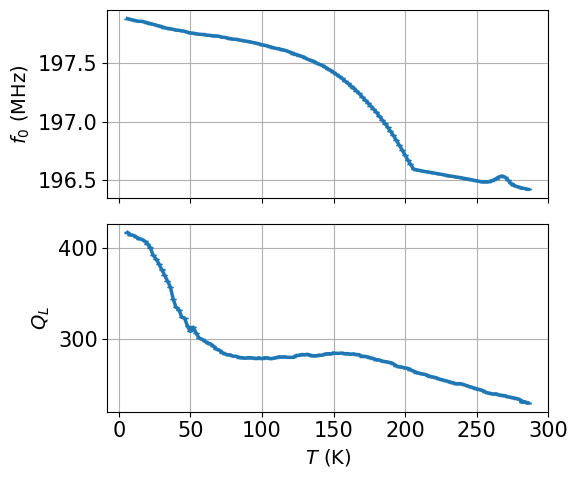

In [6]:
import matplotlib.colors as colors
base = r'/home/electron/data/cooldown_06122026/resonator'
all_files = [i for i in list_filenames(base) if 'E' not in i]
cmap = plt.cm.rainbow
norm = colors.Normalize(vmin=0, vmax=290)
# fig = plt.figure(figsize=(10,6))
all_Ql, all_Ql_err, all_fr, all_fr_err = [], [], [], []
all_T = []
for filename in all_files: 
    file = np.load(f'{base}/{filename}', allow_pickle=True)
    all_T.append(float(filename[:-4]))
    freq, data = file['freq'], file['data']#/10**(np.max(24.16*3/20))
    fit = plot_transmission_fit_load(freq, data, show_plot=False) 
    all_Ql.append(fit['Ql'])
    all_Ql_err.append(fit['Ql_err'])
    all_fr.append(fit['fr']) 
    all_fr_err.append(fit['fr_err'])
idx = np.argsort(all_T)
all_T = np.array(all_T)
fig, ax = plt.subplots(nrows=2, figsize=(6,5), sharex=True)
plot_ax_errbar(ax[0], all_T[idx], np.array(all_fr)[idx]/1e6, yerr=np.array(all_fr_err)/1e6, ylabel=r'$f_0$ (MHz)')
plot_ax_errbar(ax[1], all_T[idx], np.abs(all_Ql)[idx], yerr=np.array(all_Ql_err), xlabel=r'$T$ (K)', ylabel=r'$Q_L$')
plt.tight_layout()
plt.show()

In [7]:
import numpy as np
from scipy.optimize import curve_fit

def fit_shape_with_components(f_data, p_data_dbm, C_tank_pF=None, L_tank_nH=None, s11_dip_dB=-10.0, coupling='undercoupled'):
    """
    Fits the noise peak to extract QL, then uses the known L or C of the tank 
    circuit to calculate the true internal Zc and R0, bypassing the transformer ambiguity.
    """
    if C_tank_pF is None and L_tank_nH is None:
        raise ValueError("You must provide either C_tank_pF or L_tank_nH to calculate Zc and R0.")

    # 1. Shape-Only Lorentzian Fit
    def lorentzian_dbm(f, f0, Ql, peak_max_dbm, floor_dbm):
        transmission = 1.0 / (1.0 + (Ql**2) * (f/f0 - f0/f)**2)
        floor_w = 10**((floor_dbm - 30) / 10.0)
        peak_w = 10**((peak_max_dbm - 30) / 10.0) - floor_w
        return 10 * np.log10((peak_w * transmission) + floor_w) + 30

    floor_guess = np.percentile(p_data_dbm, 5)
    f0_guess = f_data[np.argmax(p_data_dbm)]
    peak_guess = np.max(p_data_dbm)
    
    half_power = peak_guess - 3.0
    above_half = np.where(p_data_dbm >= half_power)[0]
    Ql_guess = f0_guess / (f_data[above_half[-1]] - f_data[above_half[0]]) if len(above_half) > 1 else 500.0
        
    p0 = [f0_guess, Ql_guess, peak_guess, floor_guess]
    bounds = ([0, 0, -150, -150], [np.inf, np.inf, 10, 10])
    
    popt, _ = curve_fit(lorentzian_dbm, f_data, p_data_dbm, p0=p0, bounds=bounds, maxfev=10000)
    f0_fit, Ql_fit, peak_fit, floor_fit = popt
    
    # 2. Extract Beta and Intrinsic Q0 using S11
    S11_mag = 10**(np.abs(s11_dip_dB) / -20.0)
    beta = (1.0 - S11_mag) / (1.0 + S11_mag) if coupling == 'undercoupled' else (1.0 + S11_mag) / (1.0 - S11_mag)
    
    Q0_fit = Ql_fit * (1.0 + beta)
    
    # 3. Calculate True Zc and R0 using the known physical component
    if C_tank_pF is not None:
        C_farads = C_tank_pF * 1e-12
        # Zc = 1 / (2 * pi * f0 * C)
        Zc_fit = 1.0 / (2.0 * np.pi * f0_fit * C_farads)
    else:
        L_henries = L_tank_nH * 1e-9
        # Zc = 2 * pi * f0 * L
        Zc_fit = 2.0 * np.pi * f0_fit * L_henries

    # Intrinsic parallel resistance is Q0 times the characteristic impedance
    R0_fit = Q0_fit * Zc_fit
    
    results = {
        'f0 (Hz)': f0_fit,
        'Loaded QL': Ql_fit,
        'Intrinsic Q0': Q0_fit,
        'Zc (Ohms)': Zc_fit,
        'Resonance Resistance R0 (Ohms)': R0_fit,
        'Coupling Beta': beta,
        'Noise floor': floor_fit
    }
    
    fit_curve = lorentzian_dbm(f_data, f0_fit, Ql_fit, peak_fit, floor_fit)
    return results, fit_curve

In [8]:
import matplotlib.colors as colors
base = r'/home/electron/data/warmup_06062026/resonator'
all_files = [i for i in list_filenames(base) if 'E' not in i]
all_T = [] 
all_QL = []
all_Q0 = []
all_R0 = []
all_Zc = []
all_floor = []

for filename in all_files: 
    file = np.load(f'{base}/{filename}', allow_pickle=True)
    freq, power = file['freq'], file['data']
    color = cmap(norm(float(filename[:-4]))) 
    # plot(freq, power, c=color, alpha=0.5, xlabel='Frequency (MHz)', ylabel='Power Spectrum (dBm)') 
    gain = 24.5*3
    T = float(filename[:-4])
    results, model = fit_shape_with_components(freq*1e6, power, s11_dip_dB=-10, C_tank_pF=4, coupling='overcoupled')
    all_T.append(T) 
    all_QL.append(results['Loaded QL']) 
    all_Q0.append(results['Intrinsic Q0']) 
    all_R0.append(results['Resonance Resistance R0 (Ohms)']) 
    all_Zc.append(results['Zc (Ohms)'])
    all_floor.append(results['Noise floor'])

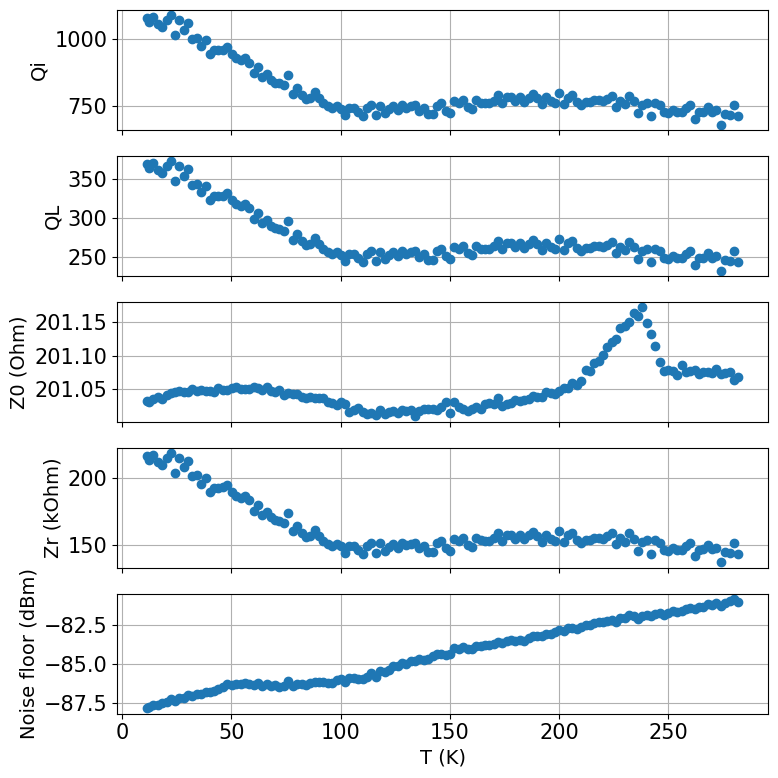

In [9]:
idx = np.argsort(all_T)
fig, ax = plt.subplots(nrows=5, sharex=True, figsize=(8, 8))
plot_ax(ax[0], all_T, np.array(all_Q0), '.', ylabel='Qi')
plot_ax(ax[1], all_T, np.array(all_QL), '.', ylabel='QL') 
plot_ax(ax[2], all_T, np.array(all_Zc), '.', ylabel='Z0 (Ohm)') 
plot_ax(ax[3], all_T, np.array(all_R0)/1e3, '.', ylabel='Zr (kOhm)') 
plot_ax(ax[4], all_T, np.array(all_floor), '.', xlabel='T (K)', ylabel='Noise floor (dBm)')
plt.tight_layout() 
plt.show()

In [27]:
import matplotlib.colors as colors
base = r'/home/electron/data/warmup_06062026/resonator'
all_files = [i for i in list_filenames(base) if 'E' not in i]
all_T = [] 
all_QL = []
all_Q0 = []
all_R0 = []
all_Zc = []
all_floor = []
all_power = []

for filename in all_files: 
    file = np.load(f'{base}/{filename}', allow_pickle=True)
    freq, power = file['freq'], file['data']
    color = cmap(norm(float(filename[:-4]))) 
    # plot(freq, power, c=color, alpha=0.5, xlabel='Frequency (MHz)', ylabel='Power Spectrum (dBm)') 
    gain = 24.5*3
    T = float(filename[:-4])
    all_power.append(np.max(power))
    results, model = fit_shape_with_components(freq*1e6, power, s11_dip_dB=-10, C_tank_pF=13, coupling='undercoupled')
    all_T.append(T) 
    all_QL.append(results['Loaded QL']) 
    all_Q0.append(results['Intrinsic Q0']) 
    all_R0.append(results['Resonance Resistance R0 (Ohms)']) 
    all_Zc.append(results['Zc (Ohms)'])
    all_floor.append(results['Noise floor'])

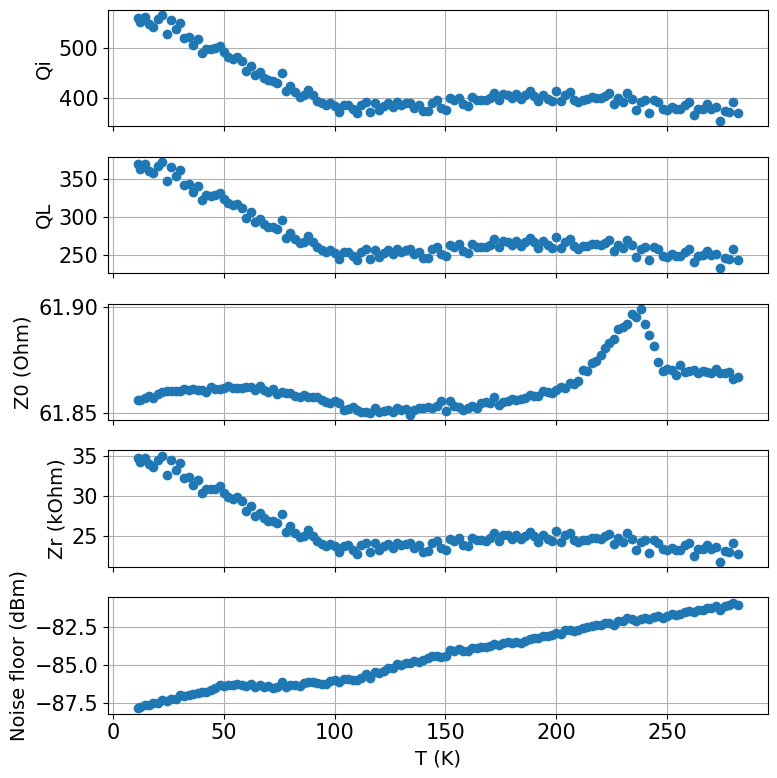

In [28]:
idx = np.argsort(all_T)
fig, ax = plt.subplots(nrows=5, sharex=True, figsize=(8, 8))
plot_ax(ax[0], all_T, np.array(all_Q0), '.', ylabel='Qi')
plot_ax(ax[1], all_T, np.array(all_QL), '.', ylabel='QL') 
plot_ax(ax[2], all_T, np.array(all_Zc), '.', ylabel='Z0 (Ohm)') 
plot_ax(ax[3], all_T, np.array(all_R0)/1e3, '.', ylabel='Zr (kOhm)') 
plot_ax(ax[4], all_T, np.array(all_floor), '.', xlabel='T (K)', ylabel='Noise floor (dBm)')
plt.tight_layout() 
plt.show()

In [26]:
idx_Tmin = np.argmin(all_T)
W_to_dBm(4*spc.k*all_T[idx_Tmin]*all_R0[idx_Tmin]*1e3/50*(1-dB_to_frac(-10))*dB_to_frac(24*3)+dBm_to_W(all_floor[idx_Tmin])), all_power[idx_Tmin]

(np.float64(-52.71943748620703), np.float64(-79.89))

In [13]:
idx_Tmax = np.argmax(all_T)
W_to_dBm(4*spc.k*all_T[idx_Tmax]*all_R0[idx_Tmax]*1e3/50*(1-dB_to_frac(-10))*dB_to_frac(24*3)+dBm_to_W(all_floor[idx_Tmax])), all_power[idx_Tmax]

(np.float64(-35.77838831754829), np.float64(-75.47273))

In [14]:
1-dB_to_frac(-10)

0.9